## Adding the isSignal column

In [16]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)
plt.style.use('belle2')
import numpy as np
import pdg
import root_pandas
import pandas

df1 = root_pandas.read_root('../exp16_17_e_idglobal_bb_2/exp16_17_e_D_tau_nu.root',key='B0')
df2 = root_pandas.read_root('../exp16_17_e_idglobal_qq_taupair_1/exp16_17_e_continuum_afterCut.root',key='B0')

In [17]:
df1.columns

Index(['__experiment__', '__run__', '__event__', '__production__',
       '__candidate__', '__ncandidates__', '__weight__', 'B0_CMS_px',
       'B0_CMS_py', 'B0_CMS_pz',
       ...
       'e_E', 'e_isSignal', 'e_mcErrors', 'e_mcPDG', 'e_dM',
       'e_isBremsCorrected', 'e_genMotherPDG', 'e_nPXDHits', 'DecayMode',
       'isSignal'],
      dtype='object', length=211)

In [18]:
df2.columns

Index(['__experiment__', '__run__', '__event__', '__production__',
       '__candidate__', '__ncandidates__', '__weight__', 'B0_CMS_px',
       'B0_CMS_py', 'B0_CMS_pz',
       ...
       'e_E', 'e_isSignal', 'e_mcErrors', 'e_mcPDG', 'e_dM',
       'e_isBremsCorrected', 'e_genMotherPDG', 'e_nPXDHits', 'DecayMode',
       'isSignal'],
      dtype='object', length=211)

In [19]:
df3 = pandas.concat([df1,df2],axis=0)
df3.to_root('exp16_17_e_sig_bkg.root',key='B0')

/cvmfs/belle.cern.ch/el7/externals/v01-11-00/Linux_x86_64/common/lib/python3.8/site-packages/root_numpy/_tree.py:575: UserWarning: converter for dtype('O') is not implemented (skipping)
  cobj = _librootnumpy.array2tree_toCObj(arr, name=name, tree=incobj)


In [3]:
df3.isna().any(axis=0)

__experiment__          False
__run__                 False
__event__               False
__production__          False
__candidate__           False
                        ...  
tag_nDaughterPhotons    False
DecayMode               False
MM2                     False
cos_D_l                 False
Signal                  False
Length: 255, dtype: bool

In [9]:
columns_nan = df3.columns[df3.isna().any(axis=0)]
columns_nan

Index(['B0_isSignal', 'B0_mcPDG', 'B0_DecayHash', 'B0_DecayHashEx',
       'B0_roeMC_E', 'B0_roeMC_M', 'B0_roeMC_P', 'B0_roeMC_PTheta',
       'B0_roeMC_Pt', 'B0_roeMC_Px', 'B0_roeMC_Py', 'B0_roeMC_Pz',
       'B0_CMS_roeMC_E', 'B0_CMS_roeMC_M', 'B0_CMS_roeMC_P',
       'B0_CMS_roeMC_PTheta', 'B0_CMS_roeMC_Pt', 'B0_CMS_roeMC_Px',
       'B0_CMS_roeMC_Py', 'B0_CMS_roeMC_Pz', 'B0_DeltaT', 'B0_DeltaTErr',
       'B0_DeltaZ', 'B0_DeltaBoost', 'B0_DeltaBoostErr', 'B0_TagVLBoost',
       'B0_TagVLBoostErr', 'B0_TagVOBoost', 'B0_TagVOBoostErr', 'B0_TagVx',
       'B0_TagVy', 'B0_TagVyErr', 'B0_TagVz', 'B0_mcDeltaTau', 'B0_mcDeltaT',
       'B0_mcDeltaBoost', 'B0_mcTagVLBoost', 'B0_mcTagVOBoost', 'B0_mcLBoost',
       'B0_mcOBoost', 'B0_mcTagVx', 'B0_mcTagVy', 'B0_mcTagVz', 'D_isSignal',
       'D_mcPDG', 'e_ErrM', 'e_SigM', 'e_isSignal', 'e_mcPDG'],
      dtype='object')

In [34]:
pandas.set_option('display.max_rows', None)
print(df3.isna().sum())

__experiment__                            0
__run__                                   0
__event__                                 0
__production__                            0
__candidate__                             0
__ncandidates__                           0
__weight__                                0
Ecms                                      0
IPX                                       0
IPY                                       0
IPZ                                       0
missingMomentumOfEvent                    0
missingMomentumOfEvent_Px                 0
missingMomentumOfEvent_Py                 0
missingMomentumOfEvent_Pz                 0
missingMomentumOfEvent_theta              0
missingMomentumOfEventCMS                 0
missingMomentumOfEventCMS_Px              0
missingMomentumOfEventCMS_Py              0
missingMomentumOfEventCMS_Pz              0
missingMomentumOfEventCMS_theta           0
missingEnergyOfEventCMS                   0
missingMass2OfEvent             

## grid search result

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)
plt.style.use('belle2')
import numpy as np
import pdg
import root_pandas
import pandas

df1 = pandas.read_csv('MVA1_grid_search_result_1.csv')
df1.eval('diff_train_test_sklearn = training_auc_sklearn - test_auc_sklearn', inplace=True)
# df2 = pandas.read_csv('MVA1_5/MVA1_5_grid_search_result_1.csv')
# df2.eval('diff_train_test_sklearn = training_auc_sklearn - test_auc_sklearn', inplace=True)
# df3 = pandas.read_csv('MVA2/MVA2_1_grid_search_result_1.csv')
# df3.eval('diff_train_test_sklearn = training_auc_sklearn - test_auc_sklearn', inplace=True)

Welcome to JupyROOT 6.24/06


In [11]:
df1.query('diff_train_test_sklearn<0.006').describe()

,Unnamed: 0,nTrees,depth,learning_rate,nCutLevels,sub_sampling_rate,training_auc_basf2,training_auc_sklearn,test_auc_basf2,test_auc_sklearn,diff_train_test_sklearn
count,4.000000,4.0,4.0,4.0000,4.0,4.0,4.000000,4.000000,4.000000,4.000000,4.000000
mean,7.500000,1325.0,2.0,0.0525,4.0,0.5,0.894162,0.894174,0.888460,0.888510,0.005664
std,7.937254,150.0,0.0,0.0050,0.0,0.0,0.000595,0.000595,0.000363,0.000363,0.000250
min,0.000000,1200.0,2.0,0.0500,4.0,0.5,0.893322,0.893335,0.887983,0.888033,0.005301
25%,2.250000,1200.0,2.0,0.0500,4.0,0.5,0.894044,0.894056,0.888332,0.888382,0.005598
50%,6.000000,1300.0,2.0,0.0500,4.0,0.5,0.894299,0.894312,0.888499,0.888549,0.005762
75%,11.250000,1425.0,2.0,0.0525,4.0,0.5,0.894417,0.894429,0.888627,0.888677,0.005828
max,18.000000,1500.0,2.0,0.0600,4.0,0.5,0.894727,0.894740,0.888859,0.888909,0.005831


In [12]:
df1.query('diff_train_test_sklearn<0.006 and test_auc_sklearn>0.8').sort_values('test_auc_sklearn')

,Unnamed: 0,nTrees,depth,learning_rate,nCutLevels,sub_sampling_rate,training_auc_basf2,training_auc_sklearn,test_auc_basf2,test_auc_sklearn,diff_train_test_sklearn
0,0,1200,2,0.05,4,0.5,0.893322,0.893335,0.887983,0.888033,0.005301
3,3,1200,2,0.06,4,0.5,0.894314,0.894326,0.888448,0.888499,0.005827
9,9,1400,2,0.05,4,0.5,0.894285,0.894297,0.888550,0.888600,0.005697
18,18,1500,2,0.05,4,0.5,0.894727,0.894740,0.888859,0.888909,0.005831


## Read data file

In [20]:
import basf2_mva
identifier = 'MVA1_5/MVA1_5_FastBDT.xml'
test= 'MVA2/sigMC_e_D_tau_nu_cut.root'
# apply the trained mva method onto data
basf2_mva.expert(basf2_mva.vector(identifier),  # weightfile
                 basf2_mva.vector(test),
                 'B0', 'MVA2/sig_MVA1_5_applied.root')

identifier = 'MVA1_5/MVA1_5_FastBDT.xml'
test= 'MVA2/exp16_17_e_Allbbkg_cut.root'
# apply the trained mva method onto data
basf2_mva.expert(basf2_mva.vector(identifier),  # weightfile
                 basf2_mva.vector(test),
                 'B0', 'MVA2/bkg_MVA1_5_applied.root')

[INFO] Elapsed application time in ms 1032.07 for MVA1_5_FastBDT.xml
[WARNING] String passed to makeROOTCompatible contains double-underscore __, which is used internally for escaping special characters. It is recommended to avoid this. However escaping a string twice with makeROOTCompatible is safe, but will print this warning. Passed string: MVA1_5__slMVA1_5_FastBDT__ptxml_isSignal
[INFO] Elapsed application time in ms 4778.34 for MVA1_5_FastBDT.xml
[WARNING] String passed to makeROOTCompatible contains double-underscore __, which is used internally for escaping special characters. It is recommended to avoid this. However escaping a string twice with makeROOTCompatible is safe, but will print this warning. Passed string: MVA1_5__slMVA1_5_FastBDT__ptxml_isSignal


In [21]:
import basf2_mva
identifier = 'MVA1_FastBDT.xml'
test= 'exp16_17_e_sig_bkg.root'
# apply the trained mva method onto data
basf2_mva.expert(basf2_mva.vector(identifier),  # weightfile
                 basf2_mva.vector(test),
                 'B0', 'MVA1_applied.root')

[INFO] Elapsed application time in ms 1325.94 for MVA1_FastBDT.xml
[WARNING] String passed to makeROOTCompatible contains double-underscore __, which is used internally for escaping special characters. It is recommended to avoid this. However escaping a string twice with makeROOTCompatible is safe, but will print this warning. Passed string: MVA1_FastBDT__ptxml_isSignal


In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)
plt.style.use('belle2')
import numpy as np
import pdg
import root_pandas
import pandas

df1=root_pandas.read_root('exp16_17_e_sig_bkg.root', key='B0')
df1 = df1.drop_duplicates(subset=['__experiment__','__run__','__event__','__production__','__candidate__']).reset_index(drop=True)
df2=root_pandas.read_root('MVA1_applied.root')
print(len(df1)==len(df2))
df = pandas.concat([df1,df2],axis=1)


df['B0_isSignal'] = df['B0_isSignal'].fillna(-1)
df['D_isSignal'] = df['D_isSignal'].fillna(-1)
df['e_isSignal'] = df['e_isSignal'].fillna(-1)
df['B0_mcPDG'] = df['B0_mcPDG'].fillna(0)

df.eval('B_D_ReChi2 = B0_vtxReChi2 + D_vtxReChi2', inplace=True)
df.eval('p_D_l = D_CMS_p + e_CMS_p', inplace=True)

Welcome to JupyROOT 6.24/00
True


In [51]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)
plt.style.use('belle2')
import numpy as np
import pdg
import root_pandas
import pandas

df1=root_pandas.read_root('exp16_17_e_withMVA15.root', key='B0')
df1 = df1.drop_duplicates(subset=['__experiment__','__run__','__event__','__production__','__candidate__']).reset_index(drop=True)
#df2=root_pandas.read_root('MVA1_5_applied.root')
df3=root_pandas.read_root('MVA2_1_applied.root')
#df4=root_pandas.read_root('MVA2/sig_MVA1_5_applied.root')
#print(len(df1)==len(df2))
print(len(df1)==len(df3))
#print(len(df1)==len(df4))
df = pandas.concat([df1,df3],axis=1)


df['B0_isSignal'] = df['B0_isSignal'].fillna(-1)
df['D_isSignal'] = df['D_isSignal'].fillna(-1)
df['e_isSignal'] = df['e_isSignal'].fillna(-1)
df['B0_mcPDG'] = df['B0_mcPDG'].fillna(0)

df.eval('B_D_ReChi2 = B0_vtxReChi2 + D_vtxReChi2', inplace=True)
df.eval('p_D_l = D_CMS_p + e_CMS_p', inplace=True)

True


In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)
plt.style.use('belle2')
import numpy as np
import pdg
import root_pandas
import pandas

df=root_pandas.read_root('exp16_17_e_withMVA2.root', key='B0')
df = df.drop_duplicates(subset=['__experiment__','__run__','__event__','__production__','__candidate__']).reset_index(drop=True)


df['B0_isSignal'] = df['B0_isSignal'].fillna(-1)
df['D_isSignal'] = df['D_isSignal'].fillna(-1)
df['e_isSignal'] = df['e_isSignal'].fillna(-1)
df['B0_mcPDG'] = df['B0_mcPDG'].fillna(0)

df.eval('B_D_ReChi2 = B0_vtxReChi2 + D_vtxReChi2', inplace=True)
df.eval('p_D_l = D_CMS_p + e_CMS_p', inplace=True)

Welcome to JupyROOT 6.24/00


In [23]:
df.columns

Index(['__experiment__', '__run__', '__event__', '__production__',
       '__candidate__', '__ncandidates__', '__weight__', 'B0_CMS_px',
       'B0_CMS_py', 'B0_CMS_pz',
       ...
       'e_mcPDG', 'e_dM', 'e_isBremsCorrected', 'e_genMotherPDG', 'e_nPXDHits',
       'isSignal', 'MVA1_FastBDT__ptxml', 'MVA1_FastBDT__ptxml_isSignal',
       'B_D_ReChi2', 'p_D_l'],
      dtype='object', length=214)

In [53]:
df=df.rename(columns={"MVA2__slMVA2_1_FastBDT__ptxml": "MVA2_1_output"})
df=df.drop(columns=['MVA2__slMVA2_1_FastBDT__ptxml_isSignal'])
df.columns

Index(['__experiment__', '__run__', '__event__', '__production__',
       '__candidate__', '__ncandidates__', '__weight__', 'B0_CMS_px',
       'B0_CMS_py', 'B0_CMS_pz',
       ...
       'e_dM', 'e_isBremsCorrected', 'e_genMotherPDG', 'e_nPXDHits',
       'DecayMode', 'isSignal', 'B_D_ReChi2', 'p_D_l', 'MVA1_5_output',
       'MVA2_1_output'],
      dtype='object', length=214)

In [45]:
df=df.rename(columns={"MVA1_5__slMVA1_5_FastBDT__ptxml": "MVA1_5_output"})
df=df.drop(columns=['MVA1_5__slMVA1_5_FastBDT__ptxml_isSignal'])
df.columns

Index(['__experiment__', '__run__', '__event__', '__production__',
       '__candidate__', '__ncandidates__', '__weight__', 'B0_CMS_px',
       'B0_CMS_py', 'B0_CMS_pz',
       ...
       'e_mcPDG', 'e_dM', 'e_isBremsCorrected', 'e_genMotherPDG', 'e_nPXDHits',
       'DecayMode', 'isSignal', 'B_D_ReChi2', 'p_D_l', 'MVA1_5_output'],
      dtype='object', length=213)

In [24]:
df=df.rename(columns={"MVA1_FastBDT__ptxml": "MVA1_output"})
df=df.drop(columns=['MVA1_FastBDT__ptxml_isSignal'])
df.columns

Index(['__experiment__', '__run__', '__event__', '__production__',
       '__candidate__', '__ncandidates__', '__weight__', 'B0_CMS_px',
       'B0_CMS_py', 'B0_CMS_pz',
       ...
       'e_mcErrors', 'e_mcPDG', 'e_dM', 'e_isBremsCorrected', 'e_genMotherPDG',
       'e_nPXDHits', 'isSignal', 'MVA1_output', 'B_D_ReChi2', 'p_D_l'],
      dtype='object', length=213)

In [46]:
df.MVA1_5_output=np.float64(df.MVA1_5_output)
print(type(df.MVA1_5_output[0]))
print(type(df.isSignal[0]))

<class 'numpy.float64'>
<class 'numpy.float64'>


In [54]:
df.to_root('exp16_17_e_withMVA2.root',key='B0')
#df.query('isSignal==0').to_root('MVA2/exp16_17_e_bbkg.root',key='B0')

In [48]:
identifier = 'MVA2/MVA2_1_FastBDT.xml'
test= 'exp16_17_e_withMVA15.root'
# apply the trained mva method onto data
basf2_mva.expert(basf2_mva.vector(identifier),  # weightfile
                 basf2_mva.vector(test),
                 'B0', 'MVA2_1_applied.root')

[INFO] Elapsed application time in ms 7377.97 for MVA2_1_FastBDT.xml
[WARNING] String passed to makeROOTCompatible contains double-underscore __, which is used internally for escaping special characters. It is recommended to avoid this. However escaping a string twice with makeROOTCompatible is safe, but will print this warning. Passed string: MVA2__slMVA2_1_FastBDT__ptxml_isSignal


## figure of merit

In [25]:
def statistics(df):
    counts=df.count()
    mean=df.mean()
    std=df.std()
    return f'''counts = %d \nmean = %5.3f \nstd = %5.3f''' %(counts,mean,std)

df_cut=df.query('B0_vetomuID<0.9').copy()

In [ ]:
# Signal components
sig_D_e_nu=df_cut.query('DecayMode=="sig_D_e_nu" and B0_mcErrors<32 and abs(B0_mcPDG)==511 and abs(D_mcPDG)==411').copy()
sig_D_mu_nu=df_cut.query('DecayMode=="sig_D_mu_nu" and B0_mcErrors<32').copy()
sig_D_tau_nu=df_cut.query('DecayMode=="sig_D_tau_nu" and B0_mcErrors<32').copy()
all_Dst_e_nu=df_cut.query('DecayMode=="all_Dst_e_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
all_Dst_mu_nu=df_cut.query('DecayMode=="all_Dst_mu_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
all_Dst_tau_nu=df_cut.query('DecayMode=="all_Dst_tau_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
all_Dstst_e_nu=df_cut.query('DecayMode=="all_Dstst_e_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()
all_Dstst_mu_nu=df_cut.query('DecayMode=="all_Dstst_mu_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()
all_Dstst_tau_nu=df_cut.query('DecayMode=="all_Dstst_tau_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()

# Bkg components
bkg_fakeD = df_cut.query('abs(D_mcPDG)!=411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_combinatorial = df_cut.query('DecayMode!="bkg" and B0_mcPDG==300553 and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_sigOtherBDTaudecay = df_cut.query('DecayMode=="bkg" and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_recoWrongSideB = df_cut.query('((DecayMode=="sig_D_tau_nu" or DecayMode=="sig_D_e_nu" or DecayMode=="sig_D_mu_nu" or \
        DecayMode=="all_Dst_tau_nu" or DecayMode=="all_Dst_e_nu" or DecayMode=="all_Dst_mu_nu") and \
        abs(B0_mcPDG)!=300553 and abs(D_mcPDG)==411 and 32<=B0_mcErrors<64 and B0_isContinuumEvent!=1) or \
    ((DecayMode=="all_Dstst_tau_nu" or DecayMode=="all_Dstst_e_nu" or DecayMode=="all_Dstst_mu_nu" or \
        DecayMode=="all_Dst_tau_nu" or DecayMode=="all_Dst_e_nu" or DecayMode=="all_Dst_mu_nu") and \
        abs(B0_mcPDG)!=300553 and abs(D_mcPDG)==411 and 8<=B0_mcErrors<16 and B0_isContinuumEvent!=1) or \
        (DecayMode!="bkg" and abs(B0_mcPDG)!=300553 and abs(D_mcPDG)==411 and 64<=B0_mcErrors<512 and B0_isContinuumEvent!=1)').copy()
# reconstructing the wrong side: 1. semileptonic in both side; 
#                                2. reco the hadronic B_tag, B_sig other_D_decay;
#                                3. reco B_tag -> D+ D_s, D_s -> tau nu

bkg_recoFakeTracksClusters = df_cut.query('B0_mcErrors==512 and B0_isContinuumEvent!=1').copy()
bkg_continuum = df_cut.query('B0_isContinuumEvent==1').copy()

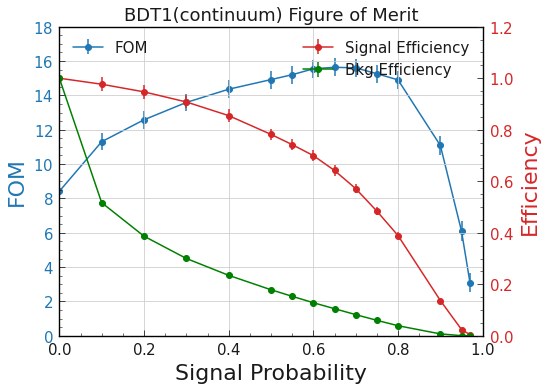

In [30]:
sig_tot = len(df.query('isSignal == 1'))
bkg_tot = len(df.query('isSignal == 0'))
cut = [0,0.1,0.2,0.3,0.4,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.9,0.95,0.97]
BDT2_FOM = []
BDT2_FOM_err = []
BDT2_sigEff = []
BDT2_sigEff_err = []
BDT2_bkgEff = []
BDT2_bkgEff_err = []
for i in cut:
    sig = len(df.query(f"isSignal == 1 and MVA1_output>{i}"))
    bkg = len(df.query(f"isSignal == 0 and MVA1_output>{i}"))
    tot = sig+bkg
    tot_err = np.sqrt(tot)
    FOM = sig / tot_err
    FOM_err = np.sqrt( (tot_err - FOM/2)**2 /tot**2 * sig + bkg**3/(4*tot**3) + 9*bkg**2*np.sqrt(sig*bkg)/(4*tot**5) )
    BDT2_FOM.append(FOM)
    BDT2_FOM_err.append(FOM_err)
    
    sigEff = sig / sig_tot
    sigEff_err = sigEff * np.sqrt(1/sig + 1/sig_tot)
    bkgEff = bkg / bkg_tot
    bkgEff_err = bkgEff * np.sqrt(1/bkg + 1/bkg_tot)
    BDT2_sigEff.append(sigEff)
    BDT2_sigEff_err.append(sigEff_err)
    BDT2_bkgEff.append(bkgEff)
    BDT2_bkgEff_err.append(bkgEff_err)

#plt.errorbar(x=cut, y=BDT2_FOM, yerr=BDT2_FOM_err,marker='o',label='BDT2')
#plt.errorbar(x=cut, y=efficiency_2, yerr=efficiency_2_err,marker='v',label='$\Gamma=m_N$')
#plt.grid()
#plt.legend()
#plt.yscale('log')
#plt.xlim(0,1)
#plt.ylim(bottom=0)


fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Signal Probability')
ax1.set_ylabel('FOM', color=color)
ax1.errorbar(x=cut, y=BDT2_FOM, yerr=BDT2_FOM_err,marker='o',label='FOM',color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid()
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Efficiency', color=color)  # we already handled the x-label with ax1
ax2.errorbar(x=cut, y=BDT2_sigEff, yerr=BDT2_sigEff_err,marker='o',label='Signal Efficiency',color=color)
ax2.errorbar(x=cut, y=BDT2_bkgEff, yerr=BDT2_bkgEff_err,marker='o',label='Bkg Efficiency',color='green')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend()

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('BDT1(continuum) Figure of Merit')
plt.xlim(0,1)
plt.ylim(bottom=0)
plt.show()

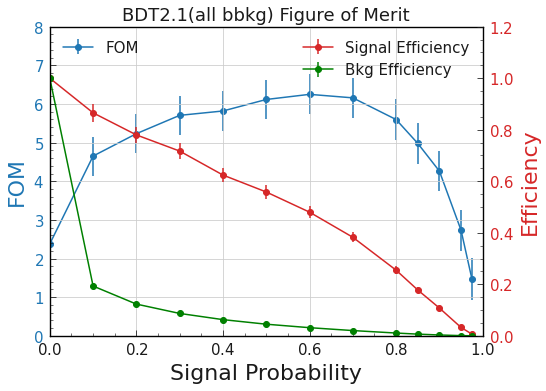

In [58]:
sig_tot = len(sig_D_tau_nu)
bkg_tot = len(df.query('isSignal == 0'))
cut = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.85,0.9,0.95,0.975]
BDT2_FOM = []
BDT2_FOM_err = []
BDT2_sigEff = []
BDT2_sigEff_err = []
BDT2_bkgEff = []
BDT2_bkgEff_err = []
for i in cut:
    sig = len(sig_D_tau_nu.query(f"MVA2_1_output>{i}"))
    bkg = len(df.query(f"isSignal == 0 and MVA2_1_output>{i}"))
    tot = sig+bkg
    tot_err = np.sqrt(tot)
    FOM = sig / tot_err
    FOM_err = np.sqrt( (tot_err - FOM/2)**2 /tot**2 * sig + bkg**3/(4*tot**3) + 9*bkg**2*np.sqrt(sig*bkg)/(4*tot**5) )
    BDT2_FOM.append(FOM)
    BDT2_FOM_err.append(FOM_err)
    
    sigEff = sig / sig_tot
    sigEff_err = sigEff * np.sqrt(1/sig + 1/sig_tot)
    bkgEff = bkg / bkg_tot
    bkgEff_err = bkgEff * np.sqrt(1/bkg + 1/bkg_tot)
    BDT2_sigEff.append(sigEff)
    BDT2_sigEff_err.append(sigEff_err)
    BDT2_bkgEff.append(bkgEff)
    BDT2_bkgEff_err.append(bkgEff_err)

#plt.errorbar(x=cut, y=BDT2_FOM, yerr=BDT2_FOM_err,marker='o',label='BDT2')
#plt.errorbar(x=cut, y=efficiency_2, yerr=efficiency_2_err,marker='v',label='$\Gamma=m_N$')
#plt.grid()
#plt.legend()
#plt.yscale('log')
#plt.xlim(0,1)
#plt.ylim(bottom=0)


fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Signal Probability')
ax1.set_ylabel('FOM', color=color)
ax1.errorbar(x=cut, y=BDT2_FOM, yerr=BDT2_FOM_err,marker='o',label='FOM',color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid()
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Efficiency', color=color)  # we already handled the x-label with ax1
ax2.errorbar(x=cut, y=BDT2_sigEff, yerr=BDT2_sigEff_err,marker='o',label='Signal Efficiency',color=color)
ax2.errorbar(x=cut, y=BDT2_bkgEff, yerr=BDT2_bkgEff_err,marker='o',label='Bkg Efficiency',color='green')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend()

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('BDT2.1(all bbkg) Figure of Merit')
plt.xlim(0,1)
plt.ylim(bottom=0)
plt.show()

### Final Cuts and Best Candidate Selection

In [3]:
df_cut=df.query('B0_vetomuID<0.9').copy()
df_bestSelected=df_cut.loc[df_cut.groupby(['__experiment__','__run__','__event__','__production__']).B_D_ReChi2.idxmin()]

In [4]:
# Signal components
sig_D_e_nu=df_bestSelected.query('DecayMode=="sig_D_e_nu" and B0_mcErrors<32 and abs(B0_mcPDG)==511 and abs(D_mcPDG)==411').copy()
sig_D_mu_nu=df_bestSelected.query('DecayMode=="sig_D_mu_nu" and B0_mcErrors<32').copy()
sig_D_tau_nu=df_bestSelected.query('DecayMode=="sig_D_tau_nu" and B0_mcErrors<32').copy()
all_Dst_e_nu=df_bestSelected.query('DecayMode=="all_Dst_e_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
all_Dst_mu_nu=df_bestSelected.query('DecayMode=="all_Dst_mu_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
all_Dst_tau_nu=df_bestSelected.query('DecayMode=="all_Dst_tau_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
all_Dstst_e_nu=df_bestSelected.query('DecayMode=="all_Dstst_e_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()
all_Dstst_mu_nu=df_bestSelected.query('DecayMode=="all_Dstst_mu_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()
all_Dstst_tau_nu=df_bestSelected.query('DecayMode=="all_Dstst_tau_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()

# Bkg components
bkg_fakeD = df_bestSelected.query('abs(D_mcPDG)!=411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_combinatorial = df_bestSelected.query('DecayMode!="bkg" and B0_mcPDG==300553 and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_sigOtherBDTaudecay = df_bestSelected.query('DecayMode=="bkg" and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_recoWrongSideB = df_bestSelected.query('((DecayMode=="sig_D_tau_nu" or DecayMode=="sig_D_e_nu" or DecayMode=="sig_D_mu_nu" or \
        DecayMode=="all_Dst_tau_nu" or DecayMode=="all_Dst_e_nu" or DecayMode=="all_Dst_mu_nu") and \
        abs(B0_mcPDG)!=300553 and abs(D_mcPDG)==411 and 32<=B0_mcErrors<64 and B0_isContinuumEvent!=1) or \
    ((DecayMode=="all_Dstst_tau_nu" or DecayMode=="all_Dstst_e_nu" or DecayMode=="all_Dstst_mu_nu" or \
        DecayMode=="all_Dst_tau_nu" or DecayMode=="all_Dst_e_nu" or DecayMode=="all_Dst_mu_nu") and \
        abs(B0_mcPDG)!=300553 and abs(D_mcPDG)==411 and 8<=B0_mcErrors<16 and B0_isContinuumEvent!=1) or \
        (DecayMode!="bkg" and abs(B0_mcPDG)!=300553 and abs(D_mcPDG)==411 and 64<=B0_mcErrors<512 and B0_isContinuumEvent!=1)').copy()
# reconstructing the wrong side: 1. semileptonic in both side; 
#                                2. reco the hadronic B_tag, B_sig other_D_decay;
#                                3. reco B_tag -> D+ D_s, D_s -> tau nu

bkg_recoFakeTracksClusters = df_bestSelected.query('B0_mcErrors==512 and B0_isContinuumEvent!=1').copy()
bkg_continuum = df_bestSelected.query('B0_isContinuumEvent==1').copy()


def statistics(df):
    counts=df.count()
    mean=df.mean()
    std=df.std()
    return f'''counts = %d \nmean = %5.3f \nstd = %5.3f''' %(counts,mean,std)

kwarg={'bins':50, 'histtype':'step','lw':2}

    
def plot_projection(cut,variable):
    (counts1, bins1) = np.histogram(sig_D_tau_nu.query(cut)[variable], bins=50)
    (counts2, bins2) = np.histogram(all_Dst_tau_nu.query(cut)[variable], bins=50)
    factor = 50
    plt.hist(bins1[:-1], bins1, weights=factor*counts1,label=f'D_tau_nu \n{statistics(sig_D_tau_nu.query(cut)[variable])}',alpha=0.6)
    sig_D_e_nu.query(cut)[variable].hist(label=f'D_e_nu \n{statistics(sig_D_e_nu.query(cut)[variable])}',**kwarg)
    
    plt.hist(bins2[:-1], bins2, weights=factor*counts2,label=f'Dst_tau_nu \n{statistics(all_Dst_tau_nu.query(cut)[variable])}',alpha=0.6,histtype='step',lw=2)
    all_Dst_e_nu.query(cut)[variable].hist(label=f'Dst_e_nu \n{statistics(all_Dst_e_nu.query(cut)[variable])}',**kwarg)
    all_Dstst_tau_nu.query(cut)[variable].hist(label=f'all_Dstst_tau_nu \n{statistics(all_Dstst_tau_nu.query(cut)[variable])}',**kwarg)
    all_Dstst_e_nu.query(cut)[variable].hist(label=f'all_Dstst_e_nu \n{statistics(all_Dstst_e_nu.query(cut)[variable])}',**kwarg)
    bkg_fakeD.query(cut)[variable].hist(label=f'bkg_fakeD \n{statistics(bkg_fakeD.query(cut)[variable])}',**kwarg)
    bkg_combinatorial.query(cut)[variable].hist(label=f'bkg_combinatorial \n{statistics(bkg_combinatorial.query(cut)[variable])}',**kwarg)
    bkg_sigOtherBDTaudecay.query(cut)[variable].hist(label=f'bkg_sigOtherBDTaudecay \n{statistics(bkg_sigOtherBDTaudecay.query(cut)[variable])}',**kwarg)
    bkg_recoWrongSideB.query(cut)[variable].hist(label=f'bkg_recoWrongSideB \n{statistics(bkg_recoWrongSideB.query(cut)[variable])}',**kwarg)
    bkg_recoFakeTracksClusters.query(cut)[variable].hist(label=f'bkg_recoFakeTracksClusters \n{statistics(bkg_recoFakeTracksClusters.query(cut)[variable])}',**kwarg)
    bkg_continuum.query(cut)[variable].hist(label=f'bkg_continuum \n{statistics(bkg_continuum.query(cut)[variable])}',**kwarg)
    plt.legend(bbox_to_anchor=(1,1),ncol=3, fancybox=True, shadow=True,labelspacing=1.5)

In [5]:
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)

In [7]:
len(bkg_fakeD)+len(sig_D_e_nu)+len(sig_D_mu_nu)+len(sig_D_tau_nu)+len(all_Dst_e_nu)+len(all_Dst_mu_nu)+len(all_Dst_tau_nu)+len(all_Dstst_e_nu)+len(all_Dstst_mu_nu)+len(all_Dstst_tau_nu)+len(bkg_combinatorial)+len(bkg_sigOtherBDTaudecay)+len(bkg_recoWrongSideB)+len(bkg_recoFakeTracksClusters)+len(bkg_continuum)==len(df_bestSelected)

True

In [26]:
bkg_continuum.D_mcPDG.value_counts()

 23.0       7316
-411.0      2518
 411.0      2120
-431.0        19
-413.0        17
-415.0        13
-10411.0      13
 10411.0      13
 431.0        13
 413.0        12
-20413.0      11
 415.0         8
 20413.0       7
-421.0         5
 10413.0       4
 421.0         3
 4122.0        2
 20423.0       2
 10433.0       1
-435.0         1
-10423.0       1
 10421.0       1
-10413.0       1
Name: D_mcPDG, dtype: int64

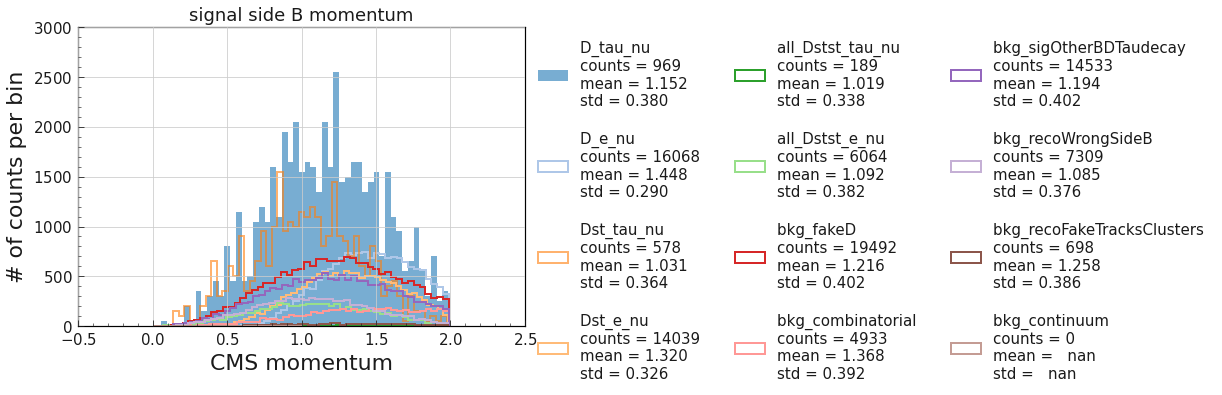

In [63]:
plot_projection('MVA1_5_output>0.35', 'B0_CMS_p')
plt.xlabel("CMS momentum")
plt.ylabel('# of counts per bin')
plt.title('signal side B momentum');
#plt.xlim(-10,10)

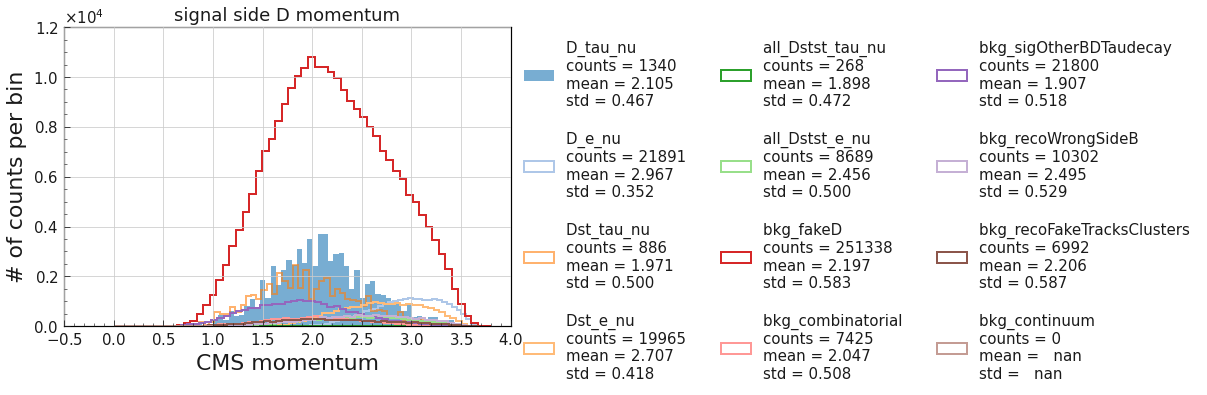

In [67]:
plot_projection('MVA1_5_output>0', 'p_D_l')
plt.xlabel("CMS momentum")
plt.ylabel('# of counts per bin')
plt.title('signal side D momentum');
#plt.xlim(-10,10)

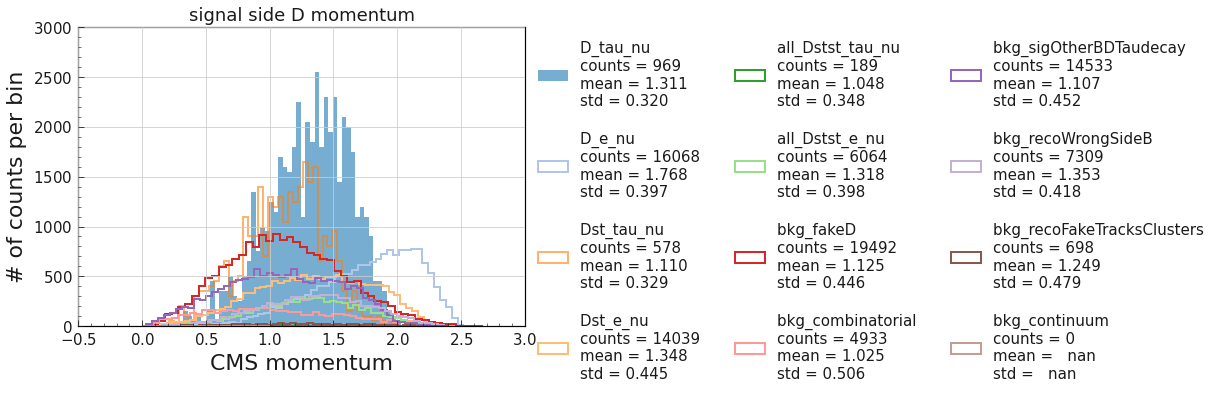

In [66]:
plot_projection('MVA1_5_output>0.35', 'D_CMS_p')
plt.xlabel("CMS momentum")
plt.ylabel('# of counts per bin')
plt.title('signal side D momentum');
#plt.xlim(-10,10)

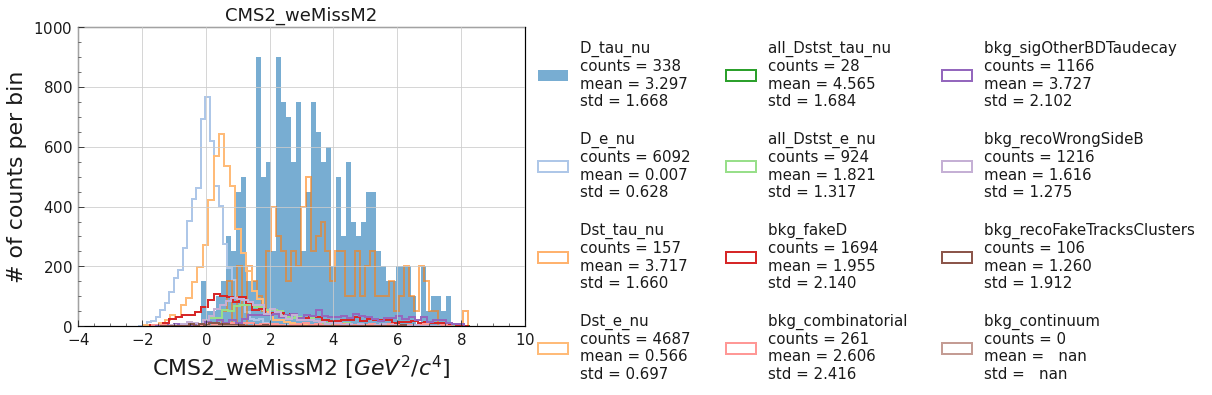

In [68]:
plot_projection('MVA2_1_output>0.6 and B0_roeMbc_my_mask>5.26', 'B0_CMS2_weMissM2')
plt.xlabel("CMS2_weMissM2 $[GeV^2/c^4]$")
plt.ylabel('# of counts per bin')
plt.title('CMS2_weMissM2');
#plt.xlim(-10,10)

In [ ]:
import decayHash
from decayHash import DecayHashMap
import ROOT
decayhash='../exp16_17_e_idglobal_bb_1/hashmap_generic_MC_e.root'

hashmap2 = DecayHashMap(decayhash, removeRadiativeGammaFlag=True)
cut='MVA2_1_output>0.6 and B0_roeMbc_my_mask>5.26'
candidate12 = bkg_sigOtherBDTaudecay.query(cut).iloc[6][['B0_DecayHash', "B0_DecayHashEx"]].values

# print the original decay as simulated in MC with removed Bremsstrahlung gammas
print("Monte Carlo Decay with removed Bremsstrahlung gammas: ")
org2 = hashmap2.get_original_decay(*candidate12)
print(org2.to_string())

Monte Carlo Decay with removed Bremsstrahlung gammas: 


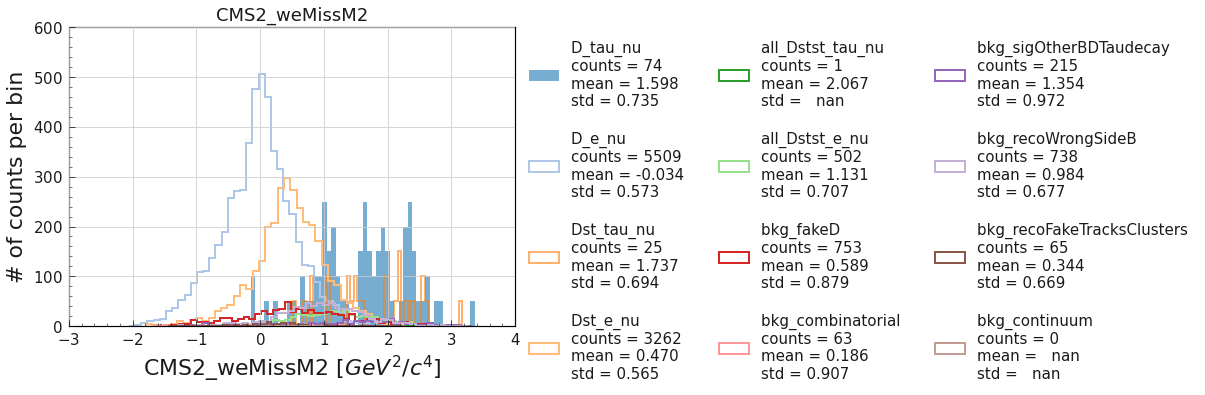

In [70]:
plot_projection('MVA2_1_output>0.6 and B0_roeMbc_my_mask>5.26 and p_D_l>2.5', 'B0_CMS2_weMissM2')
plt.xlabel("CMS2_weMissM2 $[GeV^2/c^4]$")
plt.ylabel('# of counts per bin')
plt.title('CMS2_weMissM2');
#plt.xlim(-10,10)

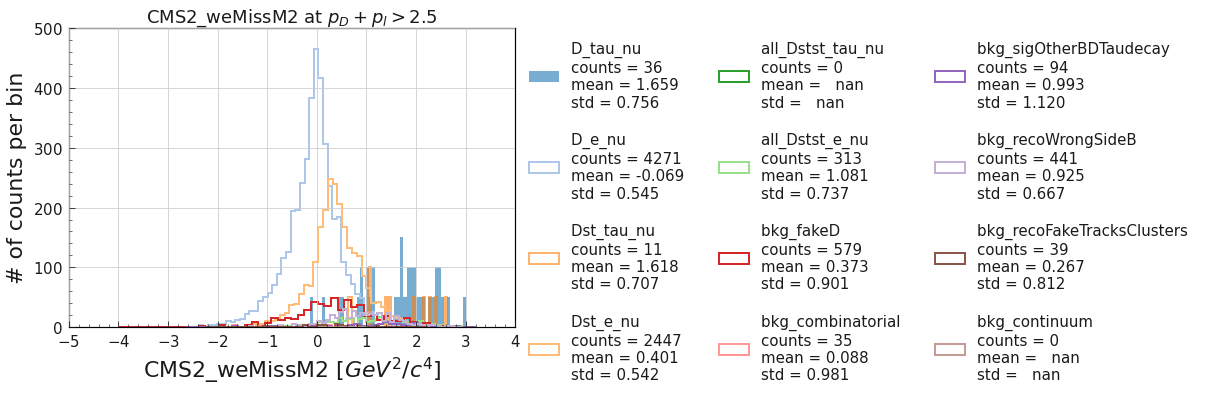

In [17]:
plot_projection('MVA2_1_output>0.5 and B0_roeMbc_my_mask>5.26 and p_D_l>2.5', 'B0_CMS2_weMissM2')
plt.xlabel("CMS2_weMissM2 $[GeV^2/c^4]$")
plt.ylabel('# of counts per bin')
plt.title('CMS2_weMissM2 at $p_D+p_l>2.5$');
#plt.xlim(-10,10)

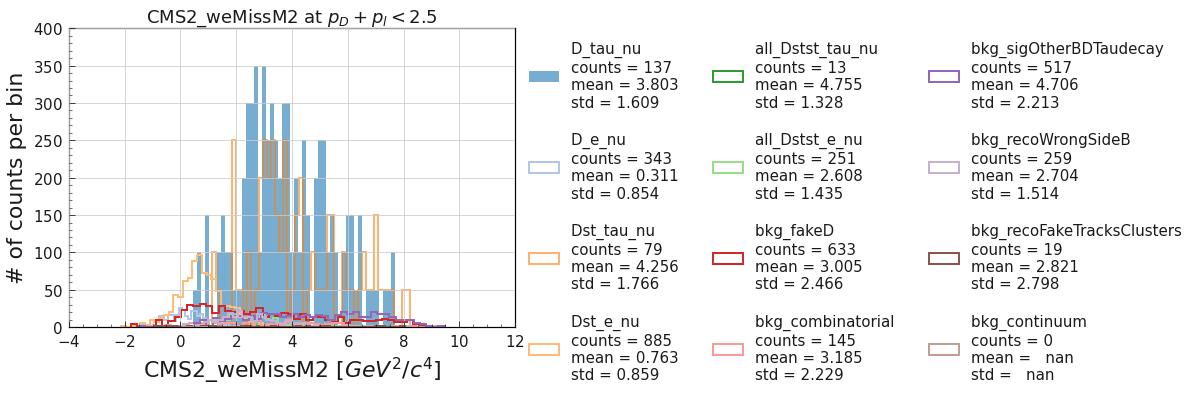

In [19]:
plot_projection('MVA2_1_output>0.5 and B0_roeMbc_my_mask>5.26 and p_D_l<2.5', 'B0_CMS2_weMissM2')
plt.xlabel("CMS2_weMissM2 $[GeV^2/c^4]$")
plt.ylabel('# of counts per bin')
plt.title('CMS2_weMissM2 at $p_D+p_l<2.5$');
#plt.xlim(-10,10)

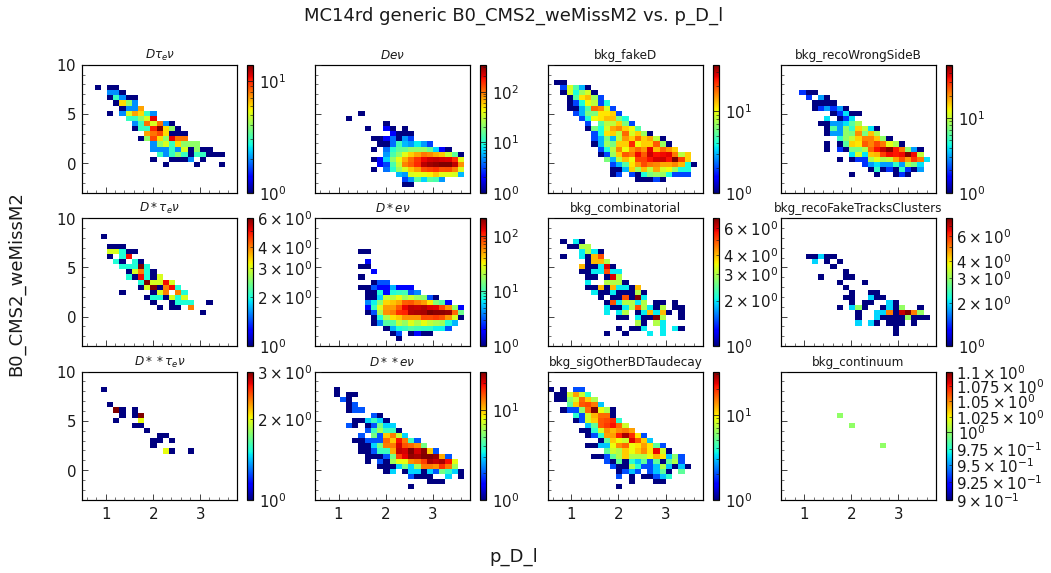

In [14]:
name_list = [r'$D\tau_e\nu$',r'$D*\tau_e\nu$',r'$D**\tau_e\nu$',
             r'$De\nu$',r'$D*e\nu$',r'$D**e\nu$',
             'bkg_fakeD','bkg_combinatorial',
             'bkg_sigOtherBDTaudecay','bkg_recoWrongSideB',
             'bkg_recoFakeTracksClusters','bkg_continuum']
df_list = [sig_D_tau_nu,all_Dst_tau_nu,all_Dstst_tau_nu, 
           sig_D_e_nu,all_Dst_e_nu,all_Dstst_e_nu, 
           bkg_fakeD,bkg_combinatorial,bkg_sigOtherBDTaudecay,
           bkg_recoWrongSideB,bkg_recoFakeTracksClusters, sig_D_tau_nu.query('B0_Mbc>5.28')]   
    
    
df_dict = dict(zip(name_list, df_list))

cuts='MVA2_1_output>0.6 and B0_roeMbc_my_mask>5.26'

variable_y = 'B0_CMS2_weMissM2'
variable_x = 'p_D_l'

n_rows,n_cols = [3,4]
fig,ax=plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16,8),sharex=True, sharey='all')
fig.suptitle(f'MC14rd generic {variable_y} vs. {variable_x}')
fig.supxlabel(f'{variable_x}')
fig.supylabel(f'{variable_y}',x=0.06)
k=0
for j in range(n_cols):
    for i in range(n_rows):
        counts, xedges, yedges, im = ax[i,j].hist2d(df_dict[name_list[k]].query(cuts)[variable_x],
                                                    df_dict[name_list[k]].query(cuts)[variable_y],
                                                    range=[[0.5,3.8],[-3,10]],bins=25,cmap='jet',
                                                    norm=colors.LogNorm())
        ax[i,j].set_title(name_list[k],fontsize=12)
        fig.colorbar(im,ax=ax[i,j])
        k+=1

#plt.xlabel('$p_{D}+p_{l}\ [GeV/c]$')
#plt.ylabel('$M_{miss}^2\ [GeV^2/c^4]$')